# Tutorial 3: Qubit Readout Architecture Search

Demonstrates global (NSGA-II) + local (combined QAT + pruning) search for qubit readout classification targeting FPGA deployment.

All parameters are controlled via `t3_config.yaml` in this directory.

**Multi-node SLURM**: `sbatch run_global_search_slurm.sh`

**Multi-node CLI**: `python run_global_search.py --n_trials 1000 --optuna_storage sqlite:///./optuna.db`

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(ROOT))

import yaml
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt

from utils.tf_global_search import GlobalSearchTF
from utils.tf_local_search_combined import combined_local_search_entrypoint
from utils.tf_data_preprocessing import load_and_preprocess_qubit

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
tf.get_logger().setLevel('ERROR')
print("TensorFlow Version:", tf.__version__)

#cfg = yaml.safe_load(open(Path.cwd() / "t3_config_small.yaml"))
cfg = yaml.safe_load(open(Path.cwd() / "t3_config.yaml"))
ds_cfg = cfg["dataset"]
s_cfg = cfg["search"]
ss_cfg = cfg["search_space"]
ls_cfg = cfg["local_search"]
out_cfg = cfg["output"]

# Resolve data_dir relative to this notebook's directory
data_dir = str((Path.cwd() / ds_cfg["data_dir"]).resolve())

RESULTS_DIR = out_cfg["results_dir"]
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"Results dir: {RESULTS_DIR}")
print(f"Data dir: {data_dir}")

2026-02-24 15:01:52.012353: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow Version: 2.15.1
Results dir: ./results/tutorial3_qubit
Data dir: /Users/dimstademler/Desktop/research_l/snac_pack_rewrite_feb2026/SNAC_dd_refactor/data/qubit


## Qubit Dataset

Loads IQ waveform data. Each sample is a 1D time series (I + Q concatenated). The model learns to classify qubit state (0 or 1) from the readout pulse.

Qubit data loaded and preprocessed:
  data_dir: /Users/dimstademler/Desktop/research_l/snac_pack_rewrite_feb2026/SNAC_dd_refactor/data/qubit
  x_train shape: (200, 800), x_test shape: (100000, 800)
  y_train shape: (200,), y_test shape: (100000,)


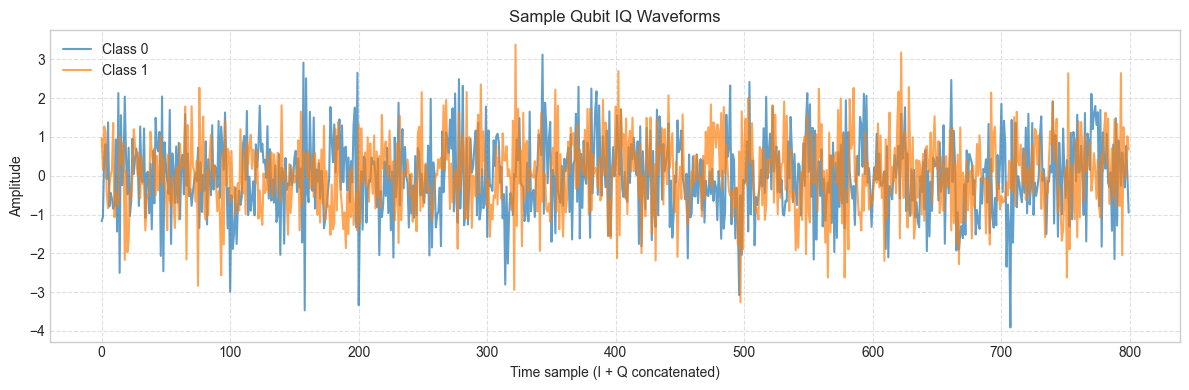

In [2]:
x_viz, y_viz, _, _ = load_and_preprocess_qubit(
    data_dir=data_dir,
    start_location=ds_cfg["start_location"],
    window_size=ds_cfg["window_size"],
    subset_size=min(ds_cfg.get("subset_size", 1000), 200),
    normalize=ds_cfg["normalize"],
    flatten=True,
    one_hot=False,
    num_classes=ds_cfg["num_classes"],
)

plt.figure(figsize=(12, 4))
for cls in range(ds_cfg["num_classes"]):
    idx = np.where(y_viz == cls)[0]
    if len(idx) > 0:
        plt.plot(x_viz[idx[0]], alpha=0.7, label=f"Class {cls}")
plt.title("Sample Qubit IQ Waveforms")
plt.xlabel("Time sample (I + Q concatenated)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## Global Search

Runs NSGA-II multi-objective search (accuracy vs BOPs) for qubit readout architectures.

For multi-node/distributed search, use `run_global_search.py` with `--optuna_storage`.

In [3]:
obj_names = s_cfg["objective_names"]
max_flags = s_cfg["maximize_flags"]
n_folds = s_cfg.get("n_folds", 1)

searcher = GlobalSearchTF(
    search_space_path=ss_cfg,
    results_dir=RESULTS_DIR,
)

# Single-node (storage=None). For multi-node, use run_global_search.py instead.
study = searcher.run_search(
    model_type=s_cfg["model_type"],
    n_trials=s_cfg["n_trials"],
    epochs=s_cfg["epochs"],
    dataset=ds_cfg["name"],
    subset_size=ds_cfg.get("subset_size"),
    objectives=obj_names,
    maximize_flags=max_flags,
    use_hardware_metrics=s_cfg["use_hardware_metrics"],
    one_hot=ds_cfg["one_hot"],
    n_folds=n_folds,
    data_dir=data_dir,
    start_location=ds_cfg["start_location"],
    window_size=ds_cfg["window_size"],
    num_classes=ds_cfg["num_classes"],
    normalize=ds_cfg["normalize"],
    flatten=ds_cfg["flatten"],
    storage=None,
)

print("Global Search Complete!")


Starting BLOCK Global Search on QUBIT



[I 2026-02-24 15:02:32,942] A new study created in memory with name: no-name-76dc43ed-6483-430f-8cf3-9008d8eb4941


Qubit data loaded and preprocessed:
  data_dir: /Users/dimstademler/Desktop/research_l/snac_pack_rewrite_feb2026/SNAC_dd_refactor/data/qubit
  x_train shape: (1000, 800), x_test shape: (100000, 800)
  y_train shape: (1000, 2), y_test shape: (100000, 2)
Using in-memory Optuna study (single-node mode)


[I 2026-02-24 15:03:37,729] Trial 0 finished with values: [0.9587722619374593, 60850176.0, 3.6325000000000003, 241.93] and parameters: {'b0': 'None', 'b1': 'None', 'b2': 'MLP', 'b3': 'MLP', 'b2_MLP_units': 2, 'b2_MLP_act': 'ReLU', 'b2_MLP_norm': None, 'b3_MLP_units': 1, 'b3_MLP_act': 'ReLU', 'b3_MLP_norm': 'batch', 'MLP_Head_width_0': 3, 'MLP_Head_width_1': 0, 'MLP_Head_acts_0': 'LeakyReLU', 'MLP_Head_acts_1': 'ReLU', 'MLP_Head_acts_2': 'LeakyReLU', 'MLP_Head_norms_0': None, 'MLP_Head_norms_1': None, 'MLP_Head_norms_2': None}.


Trial 0: Folds=[0.9601, 0.9584, 0.9578], MeanAcc=0.9588, BOPs=60850176, AvgResource=3.63%, Cycles=241.93


...

Trial 27: Folds=[0.9592, 0.9588, 0.9568], MeanAcc=0.9583, BOPs=119668736, AvgResource=4.33%, Cycles=413.04


[I 2026-02-24 15:41:38,622] Trial 28 finished with values: [0.9584158460299174, 31227904.0, 5.2725, 171.09] and parameters: {'b0': 'None', 'b1': 'MLP', 'b2': 'MLP', 'b3': 'MLP', 'b1_MLP_units': 1, 'b1_MLP_act': 'ReLU', 'b1_MLP_norm': None, 'b2_MLP_units': 2, 'b2_MLP_act': 'LeakyReLU', 'b2_MLP_norm': None, 'b3_MLP_units': 1, 'b3_MLP_act': 'LeakyReLU', 'b3_MLP_norm': 'batch', 'MLP_Head_width_0': 0, 'MLP_Head_width_1': 0, 'MLP_Head_acts_0': 'LeakyReLU', 'MLP_Head_acts_1': 'LeakyReLU', 'MLP_Head_acts_2': 'ReLU', 'MLP_Head_norms_0': None, 'MLP_Head_norms_1': None, 'MLP_Head_norms_2': None}.


Trial 28: Folds=[0.9596, 0.9587, 0.9569], MeanAcc=0.9584, BOPs=31227904, AvgResource=5.27%, Cycles=171.09


[I 2026-02-24 15:42:36,907] Trial 29 finished with values: [0.957603931427002, 28868608.0, 5.3325, 184.55] and parameters: {'b0': 'MLP', 'b1': 'MLP', 'b2': 'MLP', 'b3': 'None', 'b0_MLP_units': 1, 'b0_MLP_act': 'ReLU', 'b0_MLP_norm': 'batch', 'b1_MLP_units': 0, 'b1_MLP_act': 'ReLU', 'b1_MLP_norm': 'batch', 'b2_MLP_units': 1, 'b2_MLP_act': 'LeakyReLU', 'b2_MLP_norm': None, 'MLP_Head_width_0': 1, 'MLP_Head_width_1': 0, 'MLP_Head_acts_0': 'ReLU', 'MLP_Head_acts_1': 'LeakyReLU', 'MLP_Head_acts_2': 'LeakyReLU', 'MLP_Head_norms_0': 'batch', 'MLP_Head_norms_1': 'batch', 'MLP_Head_norms_2': 'batch'}.


Trial 29: Folds=[0.9590, 0.9576, 0.9562], MeanAcc=0.9576, BOPs=28868608, AvgResource=5.33%, Cycles=184.55

CSV results saved to ./results/tutorial3_qubit/block_search_results.csv (30 trials)

🏆 Best model architecture (Trial 23) saved for local search:
   - Source: ./results/tutorial3_qubit/trial_yamls/trial_23_arch.yaml
   - Destination: ./results/tutorial3_qubit/best_model_for_local_search.yaml
   - Accuracy: 0.9591
2D Pareto fronts plot saved to ./results/tutorial3_qubit/pareto_fronts_2d.png
3D Pareto front plot saved to ./results/tutorial3_qubit/pareto_front_3d.html

BEST TRIALS FOUND BY OPTUNA

Rank 1 (Trial 2):
  Values: {'performance_metric': 0.9581880966822306, 'bops': 44826624.0, 'avg_resource': 4.9425, 'clock_cycles': 208.18}
  Params: {'b0': 'MLP', 'b1': 'MLP', 'b2': 'MLP', 'b3': 'MLP', 'b0_MLP_units': 1, 'b0_MLP_act': 'LeakyReLU', 'b0_MLP_norm': None, 'b1_MLP_units': 3, 'b1_MLP_act': 'LeakyReLU', 'b1_MLP_norm': 'batch', 'b2_MLP_units': 1, 'b2_MLP_act': 'LeakyReLU', 'b2_MLP_

## Analyzing Global Search Results

Best Trial: 23  Accuracy: 0.9591  BOPs: 1.09e+08
Pareto front plots saved to: ./results/tutorial3_qubit


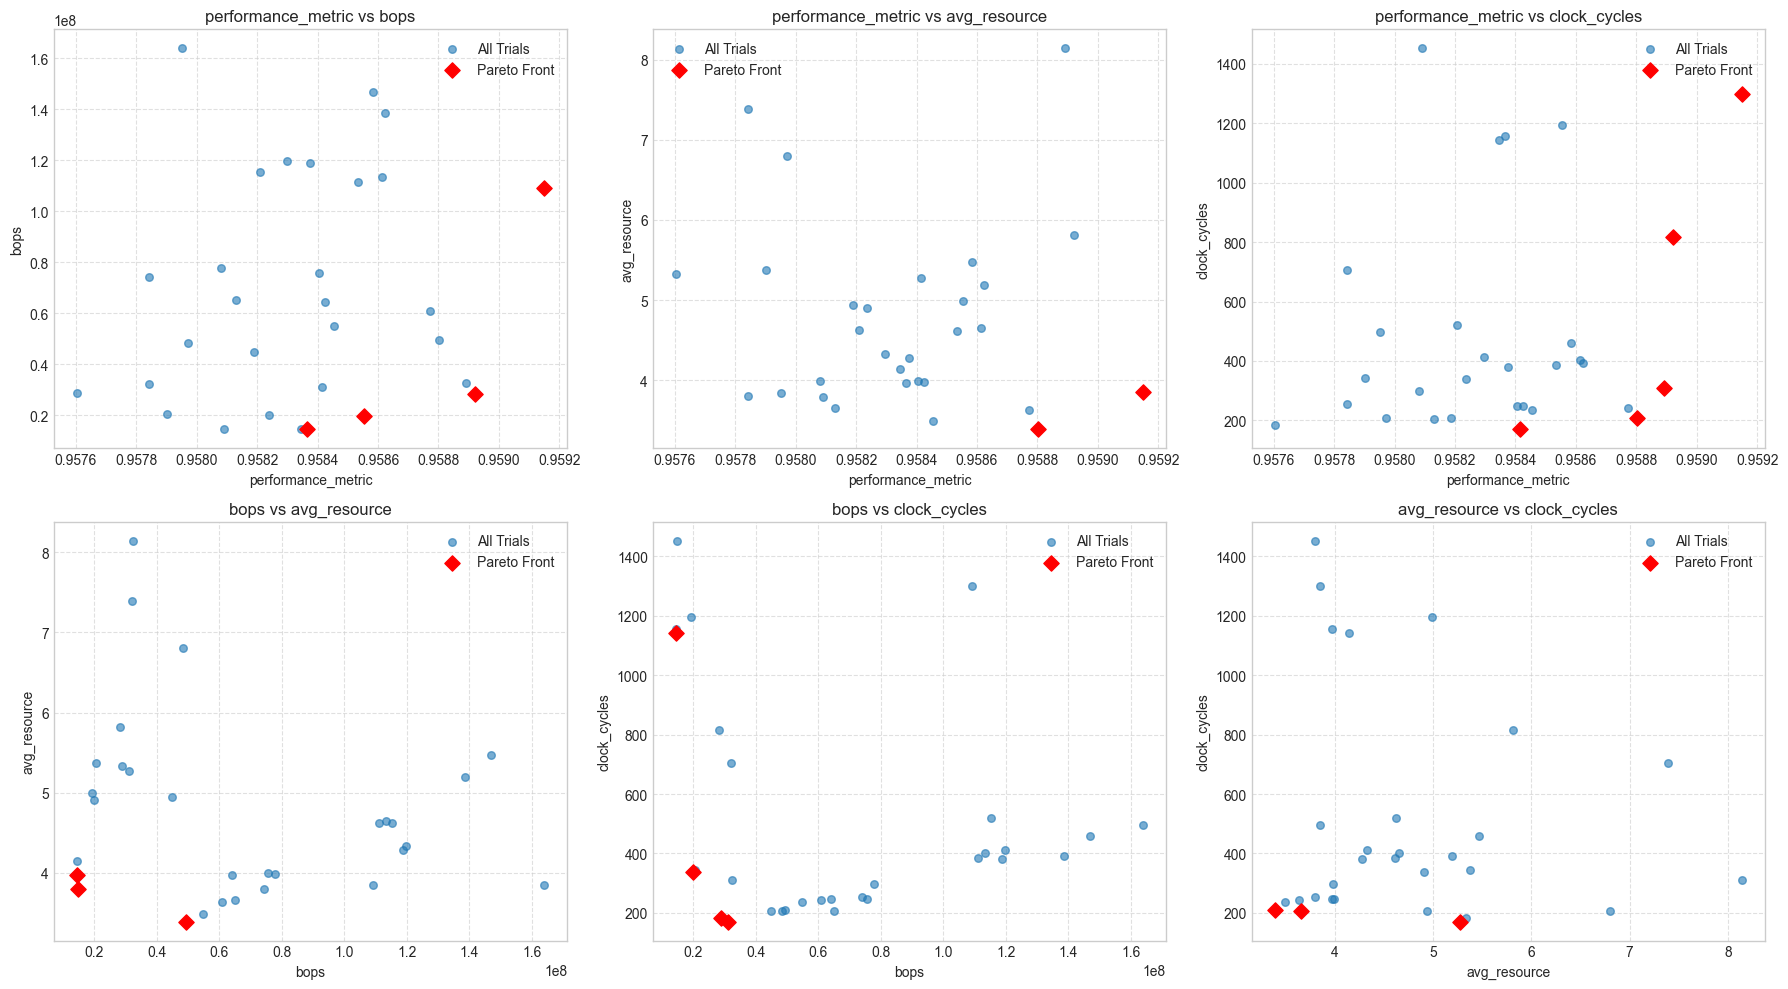

2D Pareto fronts plot saved to ./results/tutorial3_qubit/pareto_fronts_2d.png


Interactive 2D Pareto front plot saved to ./results/tutorial3_qubit/interactive_pareto_front_2d.html


3D Pareto front plot saved to ./results/tutorial3_qubit/pareto_front_3d.html


In [4]:
from utils.tf_visualization import plot_pareto_fronts, plot_interactive_2d_pareto, plot_3d_pareto_front_heatmap

results_df = pd.DataFrame(searcher.results)
if not results_df.empty:
    best = results_df.loc[results_df['performance_metric'].idxmax()]
    print(f"Best Trial: {best['trial']}  Accuracy: {best['performance_metric']:.4f}  BOPs: {best['bops']:.2e}")
    print(f"Pareto front plots saved to: {RESULTS_DIR}")

    obj_info = list(zip(obj_names, max_flags))
    plot_pareto_fronts(results_df, obj_info, save_dir=RESULTS_DIR, show=True)
    plot_interactive_2d_pareto(results_df, obj_info, save_dir=RESULTS_DIR, show=True)
    if len(obj_names) >= 4:
        plot_3d_pareto_front_heatmap(results_df, obj_info, save_dir=RESULTS_DIR, show=True)
else:
    print("No results to visualize.")

## Local Search: Combined QAT + Pruning

In [5]:
LOCAL_RESULTS_DIR = os.path.join(RESULTS_DIR, "local_search_combined")
LOCAL_CONFIG_PATH = os.path.join(RESULTS_DIR, "local_search_config.yaml")
ARCH_YAML_PATH = os.path.join(RESULTS_DIR, "best_model_for_local_search.yaml")

local_search_settings = {
    "pruning_settings": {
        "iterations": ls_cfg["pruning_iterations"],
        "epochs_per_iteration": ls_cfg["pruning_epochs"],
        "pruning_rate": ls_cfg["pruning_rate"],
    },
    "qat_settings": {
        "epochs": ls_cfg["qat_epochs"],
        "precision_pairs": ls_cfg["precision_pairs"],
    },
}
with open(LOCAL_CONFIG_PATH, "w") as f:
    yaml.dump(local_search_settings, f)

x_train, y_train, x_test, y_test = load_and_preprocess_qubit(
    data_dir=data_dir,
    start_location=ds_cfg["start_location"],
    window_size=ds_cfg["window_size"],
    subset_size=ds_cfg.get("subset_size"),
    normalize=ds_cfg["normalize"],
    flatten=ds_cfg["flatten"],
    one_hot=True,
    num_classes=ds_cfg["num_classes"],
)

if not os.path.exists(ARCH_YAML_PATH):
    raise FileNotFoundError(f"Could not find best architecture YAML: {ARCH_YAML_PATH}. Run global search first.")

# Use empty val arrays; combined_local_search_entrypoint uses k-fold CV internally
x_val_empty = np.empty((0, *x_train.shape[1:]), dtype=x_train.dtype)
y_val_empty = np.empty((0, *y_train.shape[1:]), dtype=y_train.dtype)

combined_df = combined_local_search_entrypoint(
    architecture_yaml_path=ARCH_YAML_PATH,
    local_search_config_path=LOCAL_CONFIG_PATH,
    dataset=(x_train, y_train, x_val_empty, y_val_empty),
    results_dir=LOCAL_RESULTS_DIR,
    n_folds=n_folds,
)

Qubit data loaded and preprocessed:
  data_dir: /Users/dimstademler/Desktop/research_l/snac_pack_rewrite_feb2026/SNAC_dd_refactor/data/qubit
  x_train shape: (1000, 800), x_test shape: (100000, 800)
  y_train shape: (1000, 2), y_test shape: (100000, 2)

 STARTING COMBINED QAT+PRUNING LOCAL SEARCH (k-fold CV, 3 folds) 
Baseline FP32 BOPs: 1.16e+08

==================== Precision: <16,6> ====================
  Fold 1/3: QAT warmup... acc=0.9311
  Fold 2/3: QAT warmup... acc=0.9159
  Fold 3/3: QAT warmup... acc=0.9489
  Iter  0 (baseline): acc=0.9320 (3 folds)  eff_bops=2.90e+07
  Iter  1/10: acc=0.9290 (3 folds)  sparsity=0.2995  eff_bops=2.03e+07
  Iter  2/10: acc=0.9310 (3 folds)  sparsity=0.5092  eff_bops=1.42e+07
  Iter  3/10: acc=0.9230 (3 folds)  sparsity=0.6560  eff_bops=9.97e+06
  Iter  4/10: acc=0.9300 (3 folds)  sparsity=0.7588  eff_bops=7.00e+06
  Iter  5/10: acc=0.9220 (3 folds)  sparsity=0.8307  eff_bops=4.91e+06
  Iter  6/10: acc=0.9190 (3 folds)  sparsity=0.8810  eff_bops=

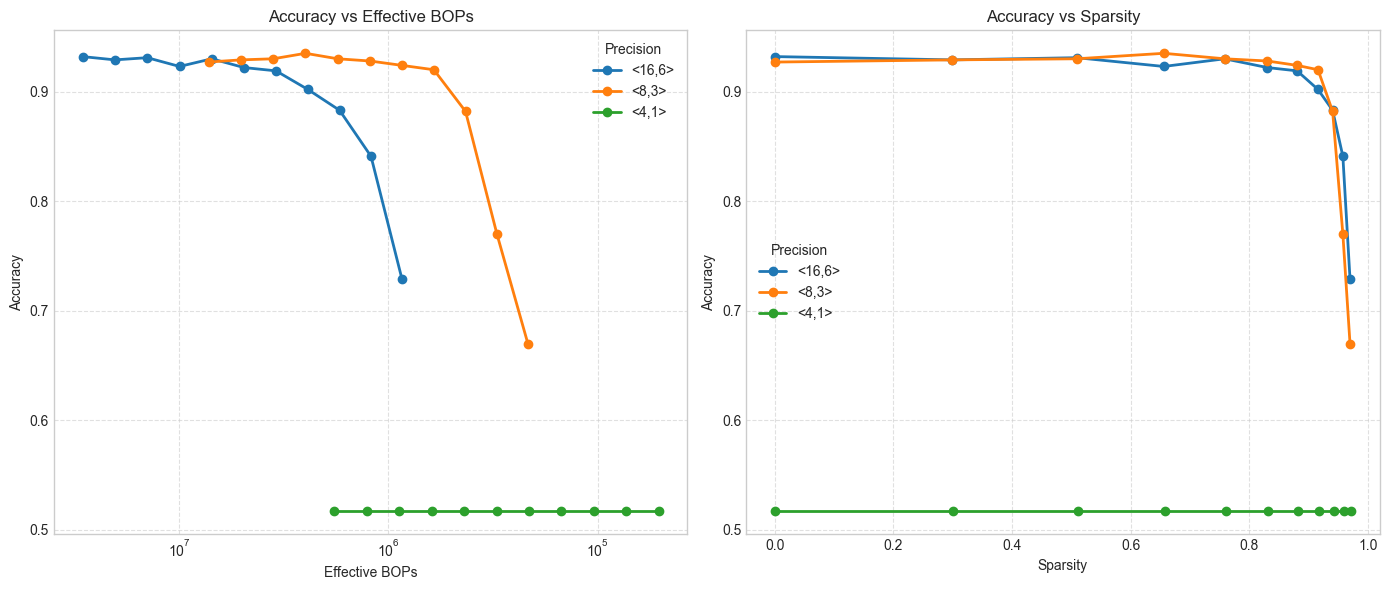

In [6]:
if isinstance(combined_df, pd.DataFrame) and not combined_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for prec in combined_df["Precision"].unique():
        sub = combined_df[combined_df["Precision"] == prec]
        axes[0].plot(sub["EffectiveBOPs"], sub["Accuracy"], marker="o", linewidth=2, label=prec)
        axes[1].plot(sub["Sparsity"], sub["Accuracy"], marker="o", linewidth=2, label=prec)
    axes[0].set(xlabel="Effective BOPs", ylabel="Accuracy", title="Accuracy vs Effective BOPs")
    axes[0].set_xscale("log")
    axes[0].invert_xaxis()
    axes[0].legend(title="Precision")
    axes[0].grid(True, linestyle="--", alpha=0.6)
    axes[1].set(xlabel="Sparsity", ylabel="Accuracy", title="Accuracy vs Sparsity")
    axes[1].legend(title="Precision")
    axes[1].grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("No combined local search results to plot.")